<a href="https://colab.research.google.com/github/TummalaSharmila/MachineLearning_in_BI/blob/PROJECT/finalcode%20with%20all%20models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


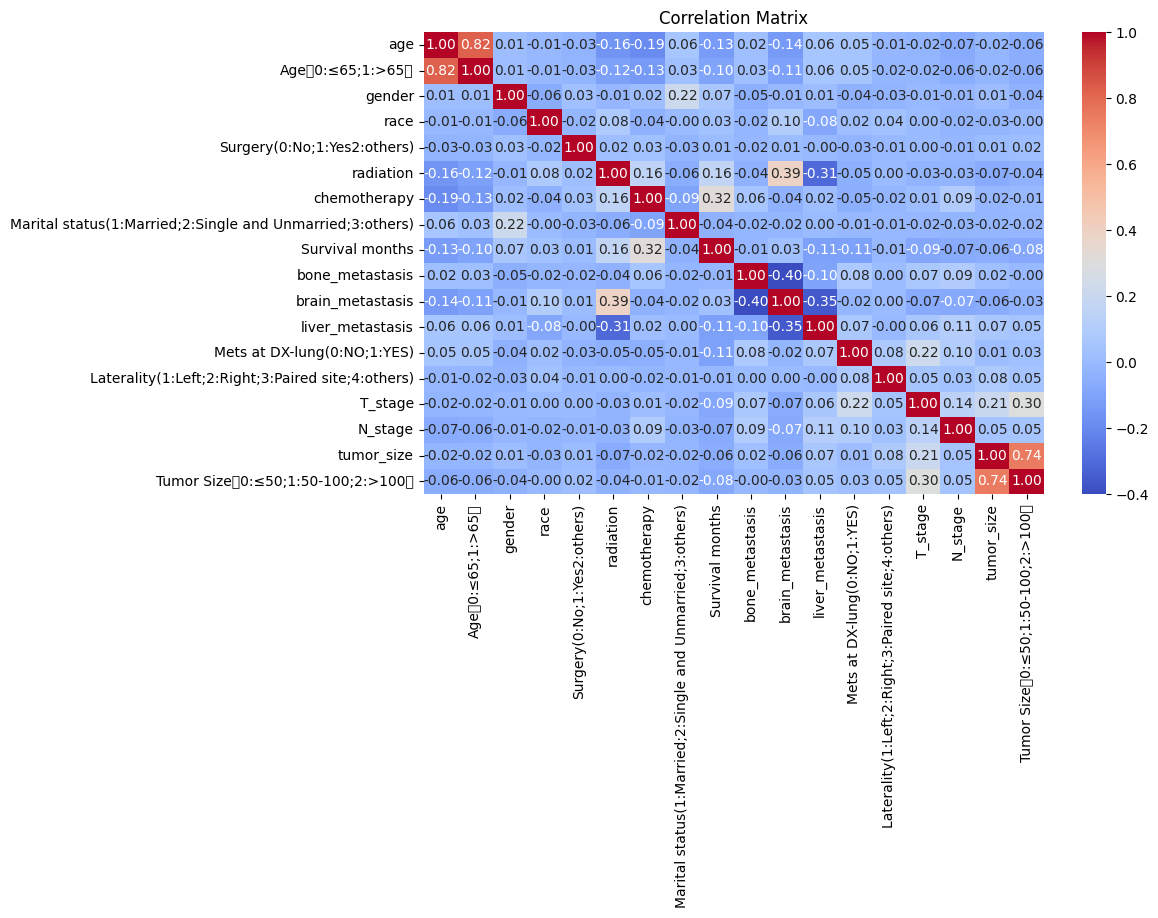

<ipython-input-7-7d0d3dd3030f>:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_features] = scaler.fit_transform(X[numeric_features])


Tuning Random Forest...
Random Forest - Acc: 0.830, Prec: 0.857, Rec: 0.693, AUC: 0.875
Tuning AdaBoost...
AdaBoost - Acc: 0.784, Prec: 0.710, Rec: 0.784, AUC: 0.861
Tuning Gradient Boosting...
Gradient Boosting - Acc: 0.849, Prec: 0.928, Rec: 0.677, AUC: 0.892
Tuning XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:33:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:33:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:33:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:33:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:33:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGBoost - Acc: 0.835, Prec: 0.884, Rec: 0.681, AUC: 0.878
Tuning LightGBM...
[LightGBM] [Info] Number of positive: 1314, number of negative: 1314
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 499
[LightGBM] [Info] Number of data points in the train set: 2628, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 1314, number of negative: 1314
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 497
[LightGBM] [Info] Number of data points in the train set: 2628, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscor

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


CatBoost - Acc: 0.848, Prec: 0.916, Rec: 0.686, AUC: 0.894


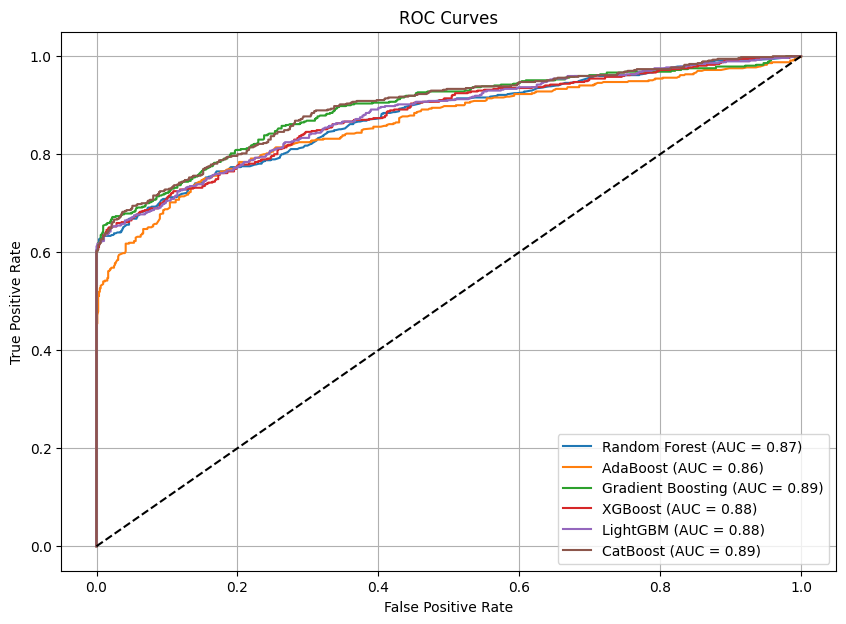

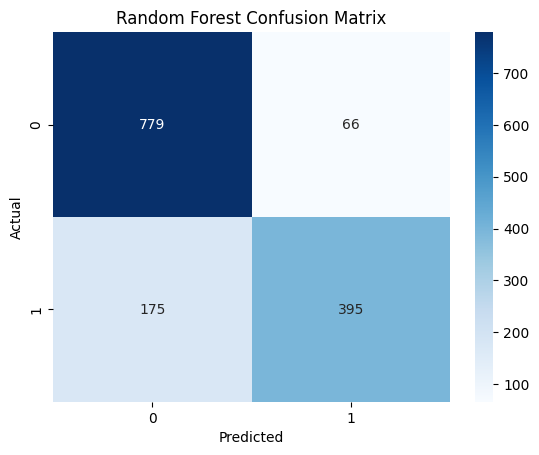

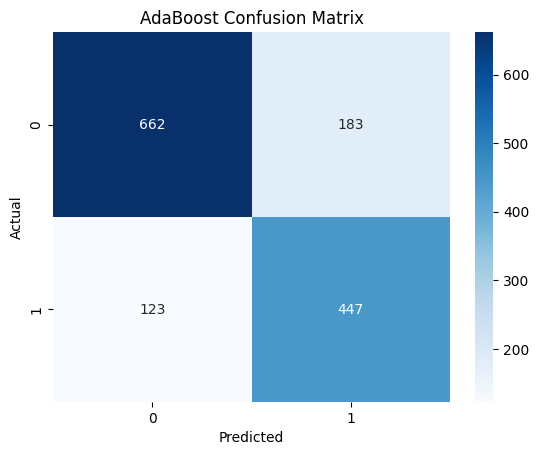

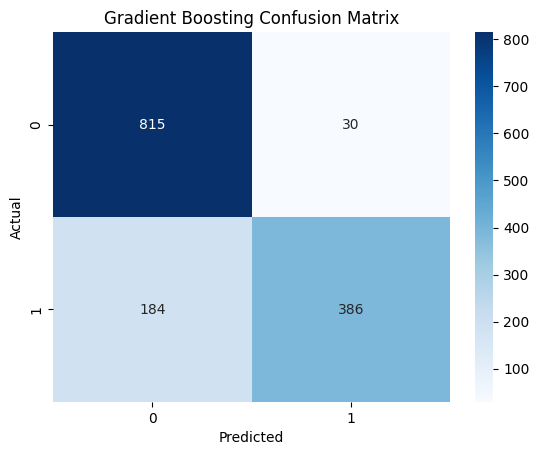

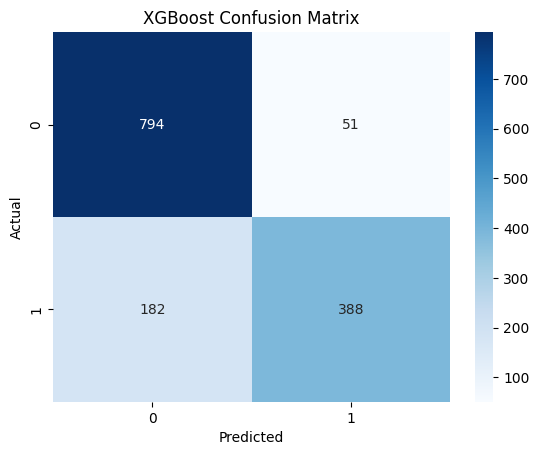

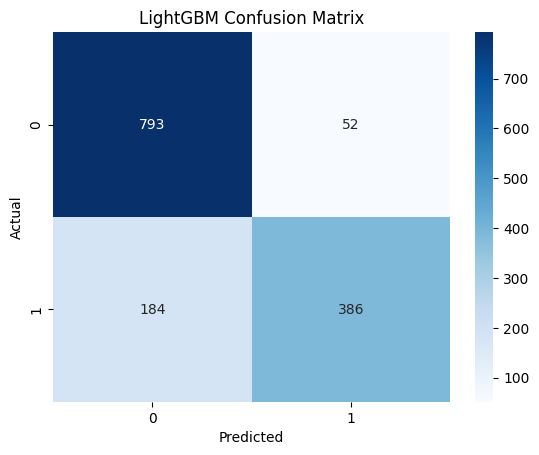

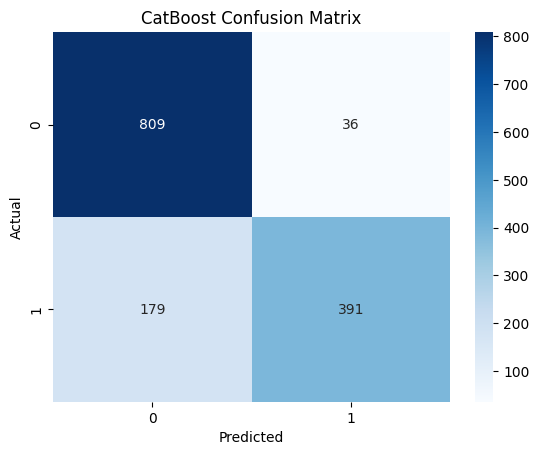

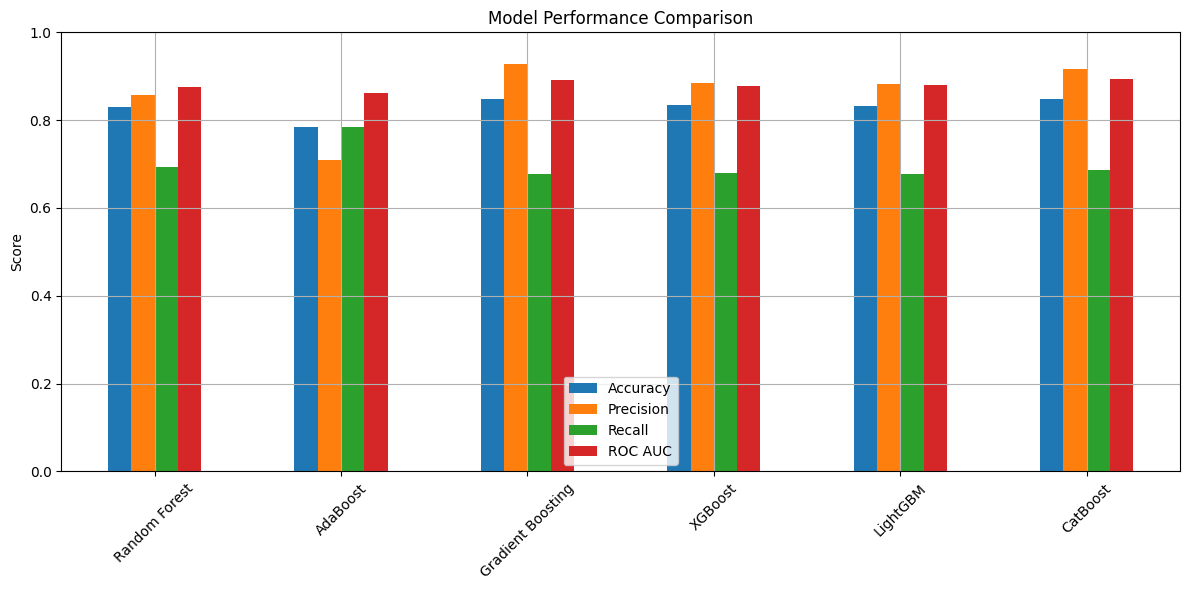

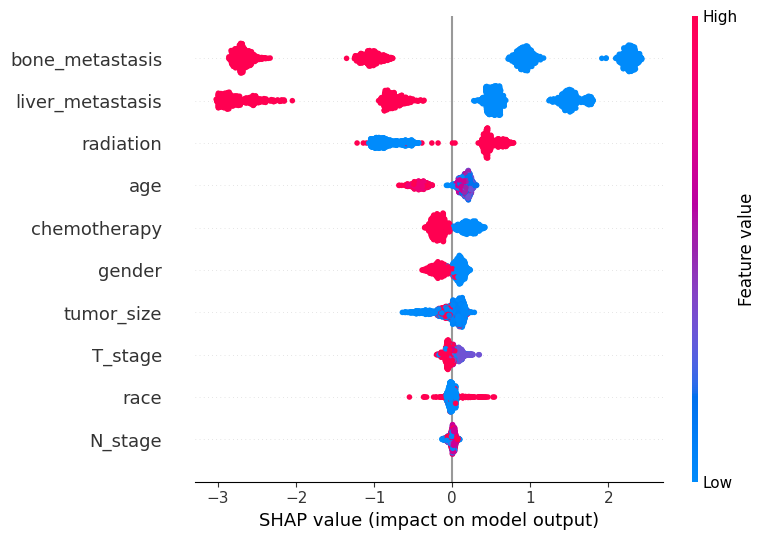

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import shap

# Load dataset
data = pd.read_csv("ES-SCLC.csv")

# Rename columns
column_mapping = {
    "Age": "age",
    "Sex(1:Male;2:Female)": "gender",
    "Race(1:White;2:Black;3:API;4:AIN)": "race",
    "Tumor Size": "tumor_size",
    "Mets at DX-bone(0:NO;1:YES)": "bone_metastasis",
    "Mets at DX-liver(0:NO;1:YES)": "liver_metastasis",
    "Radiation(0:NO;1:YES;2:others)": "radiation",
    "Chemotherapy(0:NO;1:YES)": "chemotherapy",
    "T(0:1;1:2;2:3;3:4)": "T_stage",
    "N(1:0;2:1;3:2;4:3)": "N_stage",
    "Mets at DX-brain (0:NO;1:YES)": "brain_metastasis"
}
data = data.rename(columns=column_mapping)

# Identify features
categorical_features = ["gender", "race", "radiation", "chemotherapy", "N_stage", "T_stage"]
numeric_features = ["age", "tumor_size", "bone_metastasis", "liver_metastasis"]

# Handle missing values
imputer = SimpleImputer(strategy='median')
data[numeric_features] = imputer.fit_transform(data[numeric_features])

# Encode categorical variables
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Prepare dataset
target = "brain_metastasis"
X = data[numeric_features + categorical_features]
y = data[target]

# Correlation Matrix
plt.figure(figsize=(10, 6))
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

# Standardize
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Models and hyperparameters
models = {
    "Random Forest": (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    }),
    "AdaBoost": (AdaBoostClassifier(random_state=42), {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1]
    }),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2]
    }),
    "XGBoost": (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }),
    "LightGBM": (LGBMClassifier(random_state=42), {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1]
    }),
    "CatBoost": (CatBoostClassifier(verbose=0, random_state=42), {
        'iterations': [100, 200],
        'learning_rate': [0.01, 0.1]
    }),
}

# Evaluation storage
results = {}
roc_data = {}

for name, (model, params) in models.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(model, params, scoring='roc_auc', n_iter=5, cv=3, random_state=42)
    search.fit(X_train_res, y_train_res)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "ROC AUC": roc, "Confusion Matrix": cm}
    roc_data[name] = (fpr, tpr, roc)

    print(f"{name} - Acc: {acc:.3f}, Prec: {prec:.3f}, Rec: {rec:.3f}, AUC: {roc:.3f}")

# ROC Curve Plot
plt.figure(figsize=(10, 7))
for name, (fpr, tpr, roc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# Confusion Matrix Plot
for name in results:
    cm = results[name]["Confusion Matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Model comparison bar plot
metrics_df = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "ROC AUC"]]
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# SHAP for best model
best_model_name = metrics_df["ROC AUC"].idxmax()
final_model = models[best_model_name][0].set_params(**search.best_params_)
final_model.fit(X_train_res, y_train_res)
explainer = shap.Explainer(final_model, X_test)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, show=True)


In [ ]:
# Final summarized results table
metrics_table = pd.DataFrame({
    model: {
        "Accuracy": res["Accuracy"],
        "Precision": res["Precision"],
        "Recall": res["Recall"],
        "ROC AUC": res["ROC AUC"]
    }
    for model, res in results.items()
}).T.sort_values(by="ROC AUC", ascending=False)

print("\nFinal Model Performance Summary:")
display(metrics_table.round(3))



Final Model Performance Summary:


,Accuracy,Precision,Recall,ROC AUC
CatBoost,0.848,0.916,0.686,0.894
Gradient Boosting,0.849,0.928,0.677,0.892
LightGBM,0.833,0.881,0.677,0.880
XGBoost,0.835,0.884,0.681,0.878
Random Forest,0.830,0.857,0.693,0.875
AdaBoost,0.784,0.710,0.784,0.861
